In [1]:
# 1. 升级包管理工具
!pip install --upgrade pip

# 2. 安装前置依赖项与加速器（ninja 用于多核加速编译）
!pip install fvcore iopath matplotlib ninja

# 3. 使用 Gitee 链接直接源码编译安装
# ⚠️ 注意：加入 --no-build-isolation 可以防止某些云平台的严格沙箱隔离导致的编译报错
# 整个过程大约需要 5-10 分钟，请耐心等待！
!pip install "git+https://gitee.com/hongwenzhang/pytorch3d.git" --no-build-isolation

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 23.3.2
    Uninstalling pip-23.3.2:
      Successfully uninstalled pip-23.3.2
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61443 sha256=081d5ea7cf34b3530d40b14b70545de560de4130a04960cd1ba1267c712a0f01
  Stored in directory: /root/.cache/pip/wheels/3a/e3/70/bd8fda7b2cf8b67e234290f8a72c8124b7e8e38c87451d1bbe
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31596 sha256=834d55915

[阶段二 199/200  全局 499]  Total=0.0304  Sil=0.0184  RGB=0.0124  Lap=0.0561


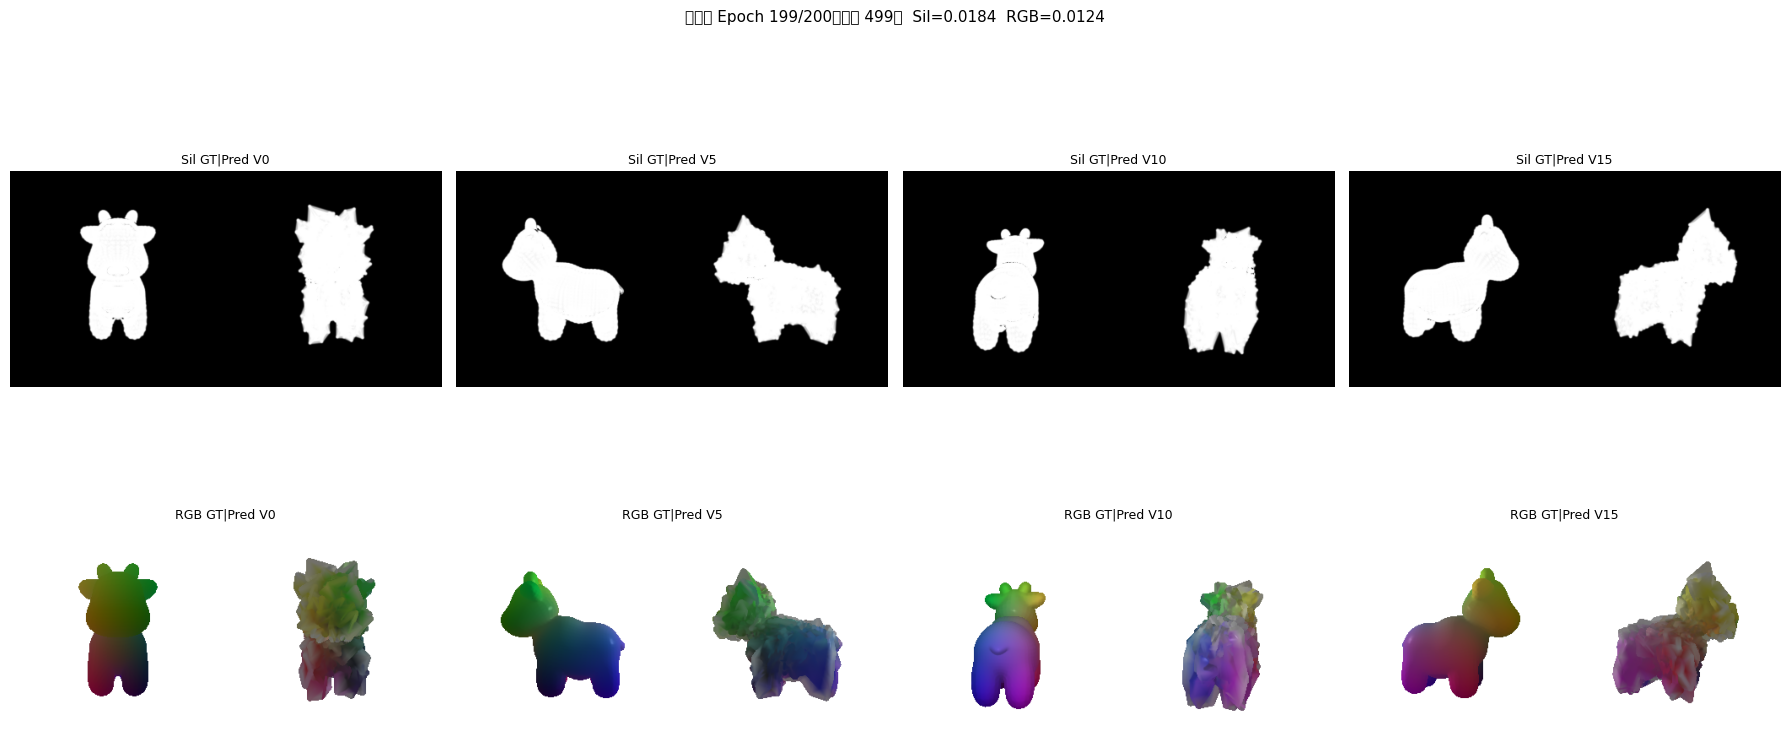


✅ 选做优化完成！


/tmp/ipykernel_1607/3729559130.py:461: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1607/3729559130.py:461: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1607/3729559130.py:461: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1607/3729559130.py:461: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1607/3729559130.py:461: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1607/3729559130.py:461: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1607/3729559130.py:461: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAP

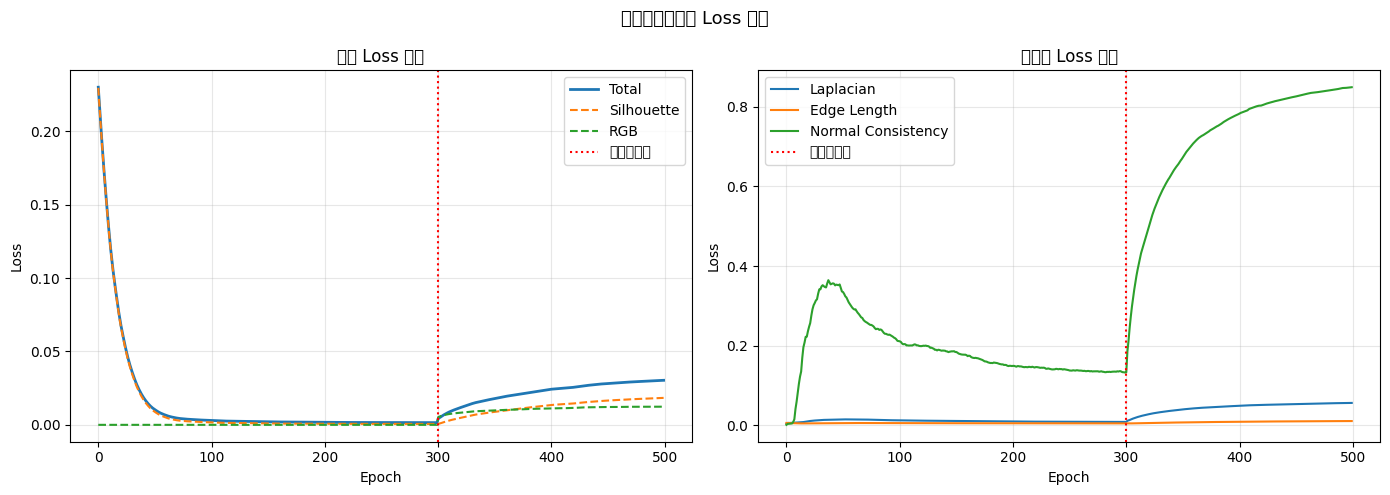

Loss 曲线已保存至 bonus_loss_curve.png


/tmp/ipykernel_1607/3729559130.py:503: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1607/3729559130.py:503: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1607/3729559130.py:503: UserWarning: Glyph 21098 (\N{CJK UNIFIED IDEOGRAPH-526A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1607/3729559130.py:503: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1607/3729559130.py:503: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1607/3729559130.py:503: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1607/3729559130.py:503: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAP

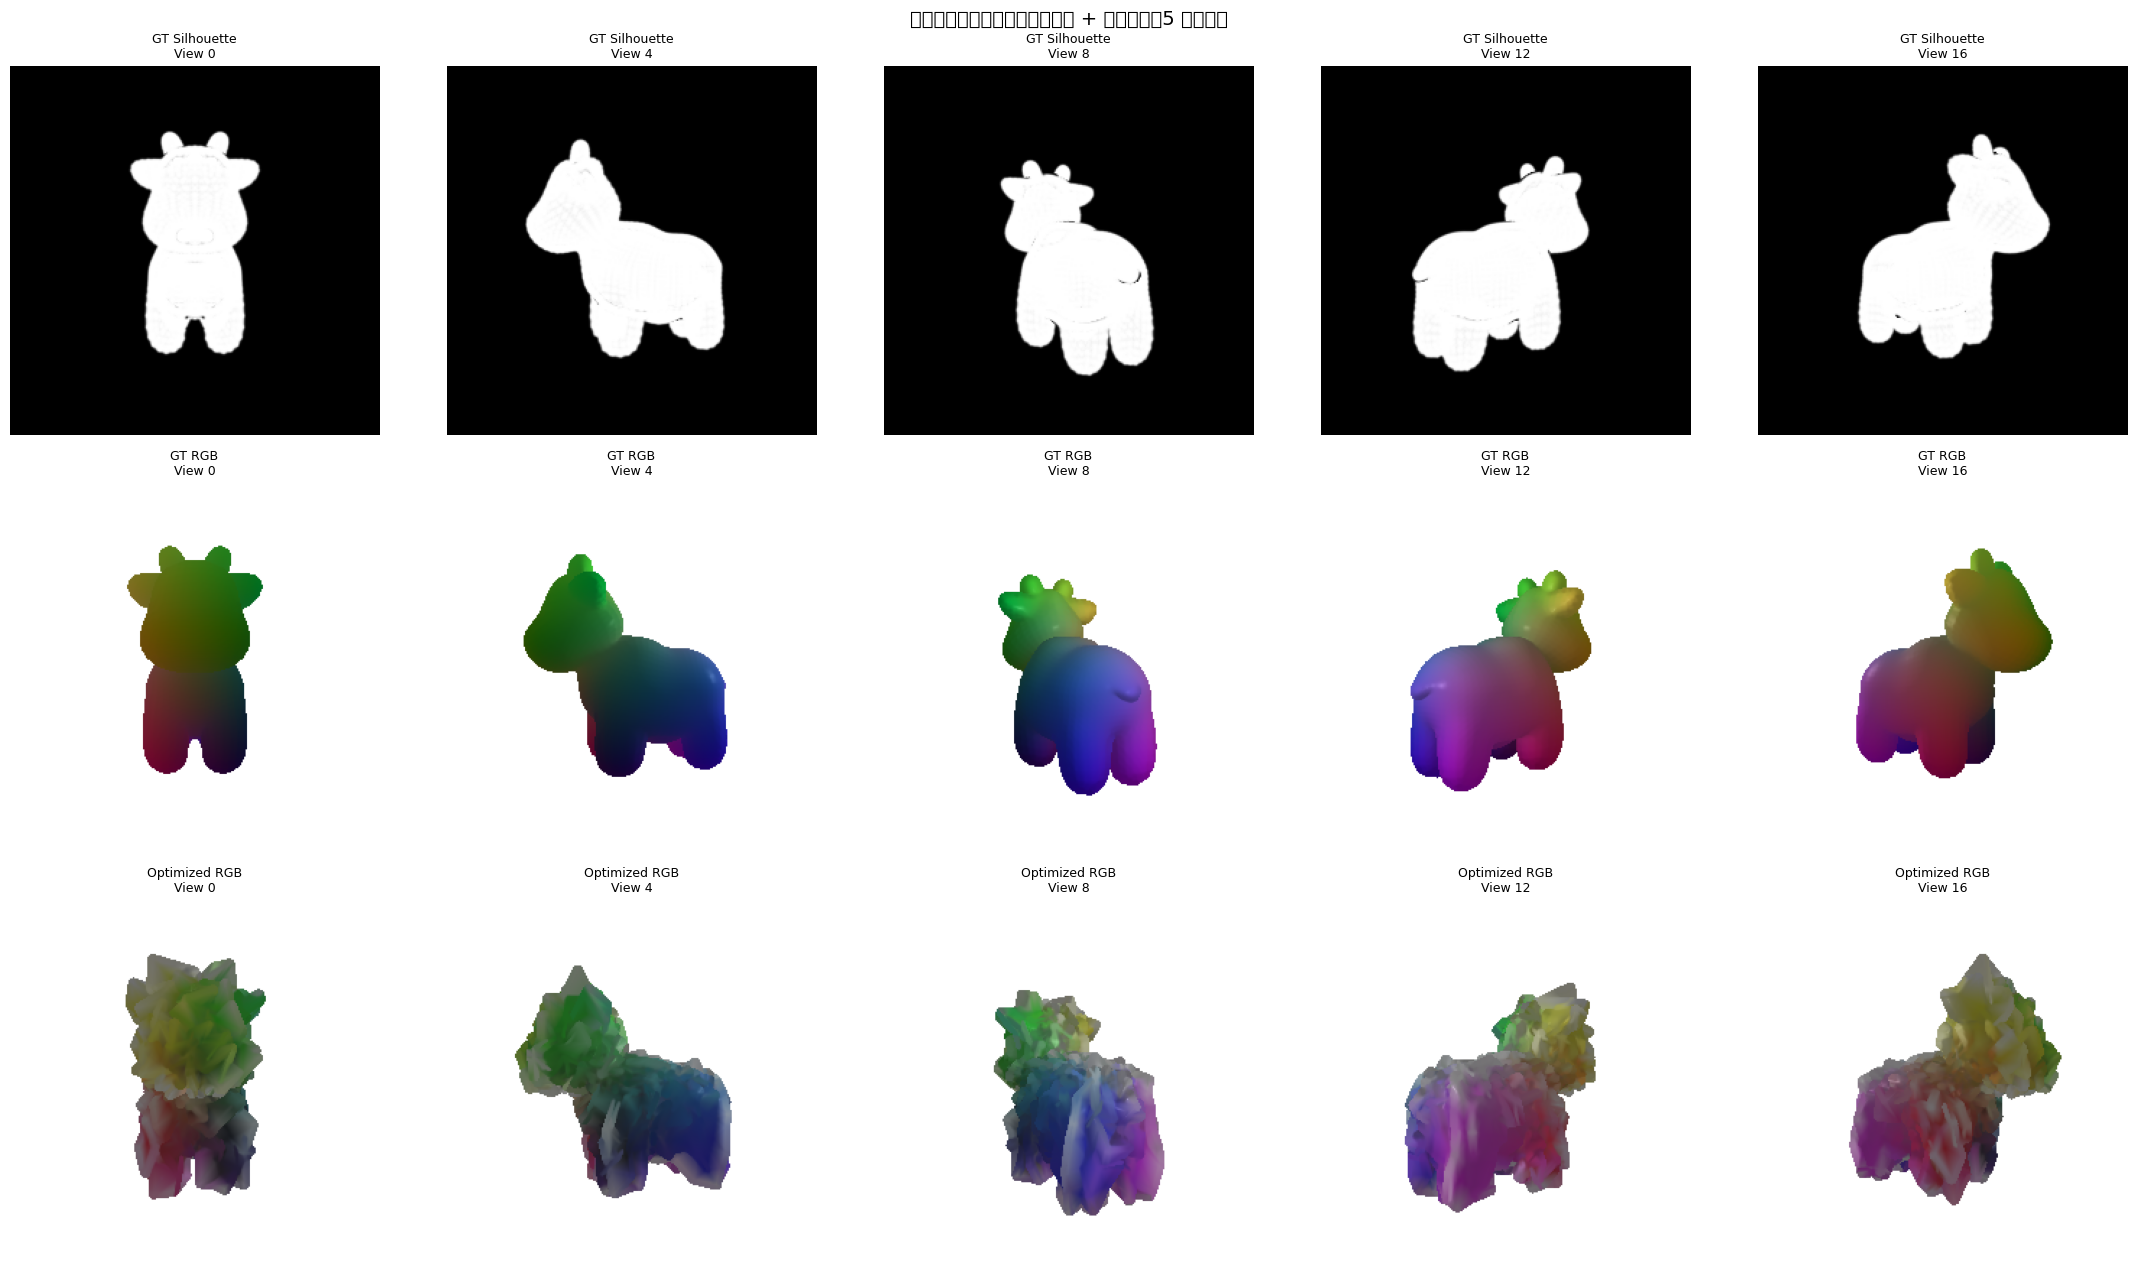

最终对比图已保存至 bonus_final_result.png


In [5]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
# 引入 save_obj 用于保存 3D 模型
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer, SoftSilhouetteShader, BlendParams
)

# 确认设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")
print(f"PyTorch3D 版本: {pytorch3d.__version__}")

# ---------------------------------------------------------
# 1. 直接读取助教打包好的本地模型文件
# ---------------------------------------------------------
obj_path = "cow.obj" 
if not os.path.exists(obj_path):
    raise FileNotFoundError("未找到 cow.obj，请确保代码文件与 obj 文件在同一目录下！")

# 准备目标数据与归一化处理
verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0]) 
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])

# ---------------------------------------------------------
# 2. 渲染管线与摄像机配置
# ---------------------------------------------------------
num_views = 20
cameras = FoVPerspectiveCameras(device=device, 
                                R=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[0], 
                                T=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[1])

rasterizer = MeshRasterizer(cameras=cameras, 
                            raster_settings=RasterizationSettings(image_size=256, blur_radius=np.log(1./1e-4 - 1.)*1e-4, faces_per_pixel=50))
shader = SoftSilhouetteShader(blend_params=BlendParams(sigma=1e-4, gamma=1e-4))

target_silhouette = shader(rasterizer(cow_mesh.extend(num_views)), cow_mesh.extend(num_views))[..., 3]

# ---------------------------------------------------------
# 3. 优化器初始化：从圆球开始
# ---------------------------------------------------------
src_mesh = ico_sphere(4, device)
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)
optimizer = torch.optim.SGD([deform_verts], lr=1.0, momentum=0.9)

# 创建保存中间结果的文件夹
output_dir = "output_meshes"
os.makedirs(output_dir, exist_ok=True)
print(f"中间模型将保存在目录: ./{output_dir}/")

# ---------------------------------------------------------
# 4. 可微渲染优化循环
# ---------------------------------------------------------
epochs = 300
for i in range(epochs):
    optimizer.zero_grad()
    
    # 依据当前计算出的偏移量，形变生成新的 Mesh
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 渲染当前 Mesh 的 20 个视角剪影
    pred_silhouette = shader(rasterizer(new_src_mesh.extend(num_views)), new_src_mesh.extend(num_views))[..., 3]
    
    # 【核心损失】：均方误差 + 三大正则化惩罚
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()
    loss = loss_silhouette + \
           1.0 * mesh_laplacian_smoothing(new_src_mesh) + \
           0.1 * mesh_edge_loss(new_src_mesh) + \
           0.01 * mesh_normal_consistency(new_src_mesh)
    
    loss.backward()
    optimizer.step()

    # 可视化与模型保存逻辑：每 20 步执行一次
    if i % 20 == 0 or i == epochs - 1:
        clear_output(wait=True)
        print(f"迭代步数: {i:03d}/{epochs} | 总 Loss: {loss.item():.4f} | 剪影误差: {loss_silhouette.item():.4f}")
        
        # 提取当前网格的顶点和面，并保存为 .obj 文件
        # verts_list()[0] 和 faces_list()[0] 用于获取 batch 中第一个（也是唯一一个）网格的数据
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"[*] 已保存当前 3D 模型至: {save_path}")
        
        # 刷新对比图
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        
        ax[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
        ax[0].set_title("Ground Truth Silhouette")
        ax[0].axis("off")
        
        ax[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
        ax[1].set_title(f"Optimizing... (Epoch {i})")
        ax[1].axis("off")
        
        plt.show()

print(f"优化完成！所有中间状态的 .obj 文件已保存在 {output_dir} 文件夹中。")

# ============================================================
# 选做（修复版）：两阶段联合纹理优化
# 阶段一（0~300轮）：只优化形状，正则化权重大幅降低
# 阶段二（300~500轮）：形状+颜色联合优化
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import clear_output

from pytorch3d.io import save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer,
    SoftSilhouetteShader, SoftPhongShader,
    BlendParams, MeshRenderer, PointLights, TexturesVertex,
)

print("=" * 55)
print("选做（修复版）：两阶段联合纹理优化")
print("=" * 55)

# ============================================================
# Step 0: 摄像机与渲染器配置
# ============================================================
num_views = 20
elev = torch.zeros(num_views)
azim = torch.linspace(-180, 180, num_views)
R, T = look_at_view_transform(dist=2.7, elev=elev, azim=azim)
cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

lights = PointLights(
    device=device,
    location=[[0.0, 1.0, 3.0]],
)

# 注意：blur_radius 适当放大，软化边界梯度更平滑
blur_radius = np.log(1.0 / 1e-4 - 1.0) * 1e-4

raster_settings = RasterizationSettings(
    image_size=256,
    blur_radius=blur_radius,
    faces_per_pixel=50,
)

# 剪影渲染器
sil_rasterizer = MeshRasterizer(cameras=cameras, raster_settings=raster_settings)
sil_shader     = SoftSilhouetteShader(blend_params=BlendParams(sigma=1e-4, gamma=1e-4))

# RGB 渲染器
rgb_renderer = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings),
    shader=SoftPhongShader(device=device, cameras=cameras, lights=lights),
)

# ============================================================
# Step 1: 生成目标剪影 + 目标 RGB
# ============================================================

# --- 目标剪影 ---
with torch.no_grad():
    target_silhouette_bonus = sil_shader(
        sil_rasterizer(cow_mesh.extend(num_views)),
        cow_mesh.extend(num_views)
    )[..., 3]

# --- 给奶牛赋顶点颜色（坐标归一化为彩色），生成目标 RGB ---
cow_verts = cow_mesh.verts_packed()
v_min = cow_verts.min(0)[0]
v_max = cow_verts.max(0)[0]
cow_colors = (cow_verts - v_min) / (v_max - v_min + 1e-8)   # (V, 3)

cow_mesh_colored = Meshes(
    verts=[cow_mesh.verts_list()[0]],
    faces=[cow_mesh.faces_list()[0]],
    textures=TexturesVertex(verts_features=cow_colors.unsqueeze(0)),
)

with torch.no_grad():
    target_rgb = rgb_renderer(cow_mesh_colored.extend(num_views))[..., :3]

print(f"目标剪影 shape : {target_silhouette_bonus.shape}")
print(f"目标 RGB shape : {target_rgb.shape}")

# 快速预览
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for k in range(4):
    axes[k].imshow(target_rgb[k * 5].cpu().numpy().clip(0, 1))
    axes[k].set_title(f"目标 RGB — View {k * 5}")
    axes[k].axis("off")
plt.suptitle("目标 RGB 参考图", fontsize=12)
plt.tight_layout()
plt.show()

# ============================================================
# Step 2: 初始化可微参数
# ============================================================
src_mesh_bonus = ico_sphere(4, device)
num_verts = src_mesh_bonus.verts_packed().shape[0]
print(f"球体顶点数: {num_verts}")

deform_verts_bonus = torch.zeros(
    (num_verts, 3), dtype=torch.float32, device=device, requires_grad=True
)
deform_colors = torch.zeros(
    (num_verts, 3), dtype=torch.float32, device=device, requires_grad=True
)

# ============================================================
# Step 3: 输出目录
# ============================================================
output_dir_bonus = "output_meshes_bonus"
os.makedirs(output_dir_bonus, exist_ok=True)

# ============================================================
# Step 4: 阶段一 —— 只优化形状（0~300轮）
#   关键修改：
#   - w_normal 从 0.01 → 0.0001（降低 100 倍，不再压制梯度）
#   - w_lap    从 1.0  → 0.1
#   - w_edge   从 0.1  → 0.01
#   - 只传 deform_verts_bonus 给优化器，颜色参数不参与
# ============================================================

print("\n【阶段一】只优化形状（300 轮）...\n")

optimizer_shape = torch.optim.Adam([deform_verts_bonus], lr=1e-2)

# 权重：正则化要足够小，让剪影 Loss 主导
w_sil_1    = 1.0
w_lap_1    = 0.1
w_edge_1   = 0.01
w_normal_1 = 0.0001

loss_history = {"total": [], "sil": [], "rgb": [], "lap": [], "edge": [], "normal": []}

PHASE1_EPOCHS = 300

for i in range(PHASE1_EPOCHS):
    optimizer_shape.zero_grad()

    new_mesh = src_mesh_bonus.offset_verts(deform_verts_bonus)

    # 剪影 Loss
    pred_sil = sil_shader(
        sil_rasterizer(new_mesh.extend(num_views)),
        new_mesh.extend(num_views)
    )[..., 3]
    loss_sil = ((pred_sil - target_silhouette_bonus) ** 2).mean()

    # 正则化
    loss_lap    = mesh_laplacian_smoothing(new_mesh)
    loss_edge   = mesh_edge_loss(new_mesh)
    loss_normal = mesh_normal_consistency(new_mesh)

    loss = (w_sil_1    * loss_sil
          + w_lap_1    * loss_lap
          + w_edge_1   * loss_edge
          + w_normal_1 * loss_normal)

    loss.backward()
    optimizer_shape.step()

    loss_history["total"].append(loss.item())
    loss_history["sil"].append(loss_sil.item())
    loss_history["rgb"].append(0.0)   # 阶段一无 RGB Loss
    loss_history["lap"].append(loss_lap.item())
    loss_history["edge"].append(loss_edge.item())
    loss_history["normal"].append(loss_normal.item())

    if i % 50 == 0 or i == PHASE1_EPOCHS - 1:
        clear_output(wait=True)
        print(
            f"[阶段一 {i:03d}/{PHASE1_EPOCHS}]  "
            f"Total={loss.item():.4f}  Sil={loss_sil.item():.4f}  "
            f"Lap={loss_lap.item():.4f}  Normal={loss_normal.item():.5f}"
        )

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        for k in range(4):
            view_idx = k * 5
            gt_sil   = target_silhouette_bonus[view_idx].detach().cpu().numpy()
            pr_sil   = pred_sil[view_idx].detach().cpu().numpy()
            axes[k].imshow(
                np.concatenate([gt_sil, pr_sil], axis=1),
                cmap="gray", vmin=0, vmax=1
            )
            axes[k].set_title(f"GT | Pred  V{view_idx}", fontsize=9)
            axes[k].axis("off")
        plt.suptitle(f"阶段一 Epoch {i} — 剪影对比（左GT 右Pred）", fontsize=11)
        plt.tight_layout()
        plt.show()

print("阶段一完成 ✓")

# ============================================================
# Step 5: 阶段二 —— 形状 + 颜色联合优化（300~500轮）
#   形状继续微调（学习率降低），同时加入颜色参数
# ============================================================

print("\n【阶段二】联合优化形状 + 颜色（200 轮）...\n")

optimizer_joint = torch.optim.Adam(
    [
        {"params": deform_verts_bonus, "lr": 3e-3},   # 形状学习率降低，稳定微调
        {"params": deform_colors,      "lr": 1e-2},   # 颜色学习率稍高，加速收敛
    ]
)

# 阶段二权重：引入 RGB Loss，适当放松正则化
w_sil_2    = 1.0
w_rgb_2    = 0.5    # 颜色 Loss 权重不宜太大，避免干扰形状
w_lap_2    = 0.1
w_edge_2   = 0.01
w_normal_2 = 0.0001

PHASE2_EPOCHS = 200

for i in range(PHASE2_EPOCHS):
    optimizer_joint.zero_grad()

    new_mesh_geo = src_mesh_bonus.offset_verts(deform_verts_bonus)

    # 附加颜色
    current_colors = torch.sigmoid(deform_colors).unsqueeze(0)  # (1, V, 3)
    new_mesh_colored = Meshes(
        verts=new_mesh_geo.verts_list(),
        faces=new_mesh_geo.faces_list(),
        textures=TexturesVertex(verts_features=current_colors),
    )

    # 剪影 Loss
    pred_sil = sil_shader(
        sil_rasterizer(new_mesh_geo.extend(num_views)),
        new_mesh_geo.extend(num_views)
    )[..., 3]
    loss_sil = ((pred_sil - target_silhouette_bonus) ** 2).mean()

    # RGB Loss
    pred_rgb = rgb_renderer(new_mesh_colored.extend(num_views))[..., :3]
    loss_rgb = ((pred_rgb - target_rgb) ** 2).mean()

    # 正则化
    loss_lap    = mesh_laplacian_smoothing(new_mesh_geo)
    loss_edge   = mesh_edge_loss(new_mesh_geo)
    loss_normal = mesh_normal_consistency(new_mesh_geo)

    loss = (w_sil_2    * loss_sil
          + w_rgb_2    * loss_rgb
          + w_lap_2    * loss_lap
          + w_edge_2   * loss_edge
          + w_normal_2 * loss_normal)

    loss.backward()
    optimizer_joint.step()

    epoch_global = PHASE1_EPOCHS + i
    loss_history["total"].append(loss.item())
    loss_history["sil"].append(loss_sil.item())
    loss_history["rgb"].append(loss_rgb.item())
    loss_history["lap"].append(loss_lap.item())
    loss_history["edge"].append(loss_edge.item())
    loss_history["normal"].append(loss_normal.item())

    if i % 50 == 0 or i == PHASE2_EPOCHS - 1:
        clear_output(wait=True)
        print(
            f"[阶段二 {i:03d}/{PHASE2_EPOCHS}  全局 {epoch_global}]  "
            f"Total={loss.item():.4f}  Sil={loss_sil.item():.4f}  "
            f"RGB={loss_rgb.item():.4f}  Lap={loss_lap.item():.4f}"
        )

        # 保存模型
        save_obj(
            os.path.join(output_dir_bonus, f"mesh_bonus_{epoch_global:04d}.obj"),
            new_mesh_geo.verts_list()[0].detach(),
            new_mesh_geo.faces_list()[0].detach(),
        )
        np.save(
            os.path.join(output_dir_bonus, f"colors_bonus_{epoch_global:04d}.npy"),
            torch.sigmoid(deform_colors).detach().cpu().numpy()
        )

        # 可视化面板
        fig, axes = plt.subplots(2, 4, figsize=(18, 9))
        for k in range(4):
            view_idx = k * 5

            gt_sil  = target_silhouette_bonus[view_idx].detach().cpu().numpy()
            pr_sil  = pred_sil[view_idx].detach().cpu().numpy()
            axes[0, k].imshow(
                np.concatenate([gt_sil, pr_sil], axis=1),
                cmap="gray", vmin=0, vmax=1
            )
            axes[0, k].set_title(f"Sil GT|Pred V{view_idx}", fontsize=9)
            axes[0, k].axis("off")

            gt_img  = target_rgb[view_idx].detach().cpu().numpy().clip(0, 1)
            pr_img  = pred_rgb[view_idx].detach().cpu().numpy().clip(0, 1)
            axes[1, k].imshow(np.concatenate([gt_img, pr_img], axis=1))
            axes[1, k].set_title(f"RGB GT|Pred V{view_idx}", fontsize=9)
            axes[1, k].axis("off")

        plt.suptitle(
            f"阶段二 Epoch {i}/{PHASE2_EPOCHS}（全局 {epoch_global}）  "
            f"Sil={loss_sil.item():.4f}  RGB={loss_rgb.item():.4f}",
            fontsize=11
        )
        plt.tight_layout()
        plt.show()

print("\n✅ 选做优化完成！")

# ============================================================
# Step 6: Loss 曲线
# ============================================================
total_epochs = PHASE1_EPOCHS + PHASE2_EPOCHS
x = list(range(total_epochs))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, loss_history["total"], label="Total",      linewidth=2)
axes[0].plot(x, loss_history["sil"],   label="Silhouette", linewidth=1.5, linestyle="--")
axes[0].plot(x, loss_history["rgb"],   label="RGB",        linewidth=1.5, linestyle="--")
axes[0].axvline(x=PHASE1_EPOCHS, color="red", linestyle=":", linewidth=1.5, label="阶段二开始")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("主要 Loss 曲线")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, loss_history["lap"],    label="Laplacian",         linewidth=1.5)
axes[1].plot(x, loss_history["edge"],   label="Edge Length",       linewidth=1.5)
axes[1].plot(x, loss_history["normal"], label="Normal Consistency", linewidth=1.5)
axes[1].axvline(x=PHASE1_EPOCHS, color="red", linestyle=":", linewidth=1.5, label="阶段二开始")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("正则化 Loss 曲线")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("两阶段联合优化 Loss 曲线", fontsize=13)
plt.tight_layout()
plt.savefig("bonus_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Loss 曲线已保存至 bonus_loss_curve.png")

# ============================================================
# Step 7: 最终结果对比大图
# ============================================================
with torch.no_grad():
    final_pred_rgb = rgb_renderer(new_mesh_colored.extend(num_views))[..., :3]
    final_pred_sil = sil_shader(
        sil_rasterizer(new_mesh_geo.extend(num_views)),
        new_mesh_geo.extend(num_views)
    )[..., 3]

fig, axes = plt.subplots(3, 5, figsize=(22, 13))
view_indices = [0, 4, 8, 12, 16]

for col, view_idx in enumerate(view_indices):
    axes[0, col].imshow(
        target_silhouette_bonus[view_idx].detach().cpu().numpy(),
        cmap="gray", vmin=0, vmax=1
    )
    axes[0, col].set_title(f"GT Silhouette\nView {view_idx}", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(
        target_rgb[view_idx].detach().cpu().numpy().clip(0, 1)
    )
    axes[1, col].set_title(f"GT RGB\nView {view_idx}", fontsize=9)
    axes[1, col].axis("off")

    axes[2, col].imshow(
        final_pred_rgb[view_idx].detach().cpu().numpy().clip(0, 1)
    )
    axes[2, col].set_title(f"Optimized RGB\nView {view_idx}", fontsize=9)
    axes[2, col].axis("off")

for row, label in enumerate(["目标剪影", "目标 RGB", "优化结果 RGB"]):
    axes[row, 0].set_ylabel(label, fontsize=11, rotation=90, labelpad=10)

plt.suptitle("两阶段联合优化最终结果：形状 + 顶点颜色（5 个视角）", fontsize=14)
plt.tight_layout()
plt.savefig("bonus_final_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("最终对比图已保存至 bonus_final_result.png")